# Custom Convolutional Neural Networks - xView Recognition

This notebook implements **3 custom CNN architectures** for the xView satellite image classification task:
1. **ResNet-style** - Residual blocks with skip connections
2. **VGG-style** - Sequential convolutions with increasing depth
3. **Inception-style** - Parallel multi-scale convolutions

All models are trained with the same protocol (85/15 split, same augmentation, same callbacks) for fair comparison.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import requests
import zipfile
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import defaultdict

# GPU configuration
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU enabled: {len(gpus)} device(s) detected")
else:
    print("No GPU detected.")

2026-04-01 19:48:17.895817: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775072898.260603      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775072898.358345      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775072899.216585      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775072899.216637      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775072899.216640      24 computation_placer.cc:177] computation placer alr

GPU enabled: 1 device(s) detected


In [2]:
# Download and extract dataset
url = 'https://drive.upm.es/s/2DDPE2zHw5dbM3G/download'
zip_name = 'dataset.zip'

if not os.path.exists('./xview_recognition'):
    r = requests.get(url, stream=True)
    with open(zip_name, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024):
            f.write(chunk)
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall(".")
    print("Dataset extracted.")
else:
    print("Dataset already exists.")

with open('./xview_recognition/xview_ann_train.json') as f:
    json_data = json.load(f)
print("Database loaded.")

Dataset extracted.
Database loaded.


In [3]:
!pip install rasterio -q
import warnings
import rasterio

categories = {
    0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck',
    4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator',
    8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'
}

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    with rasterio.open('./xview_recognition/' + filename, 'r') as src:
        img = np.zeros((src.height, src.width, src.count), dtype=src.profile['dtype'])
        for band in range(src.count):
            img[:, :, band] = src.read(band + 1)
    return img

In [4]:
# Load annotations
class GenericImage:
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])
        self.objects = []
    def add_object(self, obj):
        self.objects.append(obj)

class GenericObject:
    def __init__(self):
        self.bb = (-1, -1, -1, -1)
        self.category = -1

anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = tuple(int(x) for x in json_ann['bbox'])
    obj.category = json_ann['category_id']
    image.add_object(obj)
    anns.append(image)

labels = [img.objects[0].category for img in anns]
print(f"Total images: {len(anns)}")

Total images: 18746


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

anns_train, anns_valid = train_test_split(
    anns, test_size=0.15, random_state=42, shuffle=True, stratify=labels
)
print(f'Training images: {len(anns_train)}')
print(f'Validation images: {len(anns_valid)}')

objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]

# Compute class weights for handling imbalance
y_train_indices = [list(categories.values()).index(obj.category) for _, obj in objs_train]
weights = compute_class_weight('balanced', classes=np.unique(y_train_indices), y=y_train_indices)
class_weights = dict(enumerate(weights))
print(f"Class weights computed for {len(class_weights)} classes")

Training images: 15934
Validation images: 2812
Class weights computed for 13 classes


In [6]:
# Data generator with sample weights support
# NOTE: Keras does not support class_weight with generators, so we use sample_weight instead

IMG_SIZE = 128
BATCH_SIZE = 64

def generator_images(objs, batch_size, do_shuffle=False, augment=False, class_weights=None):
    """
    Generator that yields (images, labels) or (images, labels, sample_weights).
    
    Args:
        objs: list of (filename, object) tuples
        batch_size: number of samples per batch
        do_shuffle: whether to shuffle data each epoch
        augment: whether to apply data augmentation
        class_weights: dict mapping class index to weight (optional)
    """
    num_classes = len(categories)
    cat_list = list(categories.values())
    
    while True:
        if do_shuffle:
            np.random.shuffle(objs)
        
        for start in range(0, len(objs), batch_size):
            group = objs[start:start + batch_size]
            images, labels_batch, weights_batch = [], [], []
            
            for filename, obj in group:
                img = load_geoimage(filename)
                t = tf.image.convert_image_dtype(tf.convert_to_tensor(img), tf.float32)
                t = tf.image.resize(t, [IMG_SIZE, IMG_SIZE], method='bilinear')
                
                if augment:
                    t = tf.image.random_flip_left_right(t)
                    t = tf.image.random_flip_up_down(t)
                    t = tf.image.random_brightness(t, 0.1)
                    t = tf.image.random_contrast(t, 0.9, 1.1)
                    t = tf.clip_by_value(t, 0.0, 1.0)
                
                images.append(t.numpy())
                idx = cat_list.index(obj.category)
                labels_batch.append(tf.keras.utils.to_categorical(idx, num_classes))
                
                # Add sample weight based on class
                if class_weights is not None:
                    weights_batch.append(class_weights[idx])
            
            images = np.array(images, dtype=np.float32)
            labels = np.array(labels_batch, dtype=np.float32)
            
            if class_weights is not None:
                sample_weights = np.array(weights_batch, dtype=np.float32)
                yield images, labels, sample_weights
            else:
                yield images, labels

---
## Architecture 1: ResNet-style CNN

This architecture uses **residual blocks with skip connections** to enable training of deeper networks by mitigating the vanishing gradient problem.

In [7]:
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout, Add, Concatenate,
    SeparableConv2D, AveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, Nadam
from tensorflow.keras.losses import CategoricalFocalCrossentropy, CategoricalCrossentropy

def residual_block(x, filters, stride=1):
    """Residual block with pre-activation (BN-ReLU-Conv)."""
    shortcut = x
    
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = Conv2D(filters, (3, 3), strides=stride, padding='same', kernel_initializer='he_normal')(x)
    
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = Conv2D(filters, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), strides=stride, padding='same')(shortcut)
    
    return Add()([x, shortcut])

def create_resnet_style(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=13):
    """ResNet-style architecture with 4 residual stages."""
    inputs = Input(shape=input_shape)
    
    # Stem
    x = Conv2D(64, (7, 7), strides=2, padding='same', kernel_initializer='he_normal')(inputs)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = MaxPooling2D((3, 3), strides=2, padding='same')(x)
    
    # Residual stages
    x = residual_block(x, 64)
    x = residual_block(x, 64)
    
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)
    
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)
    
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512)
    
    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='swish', kernel_initializer='he_normal')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name='ResNet_Style')
    model.compile(
        optimizer=Nadam(learning_rate=1e-3),
        loss=CategoricalFocalCrossentropy(gamma=2.0),
        metrics=['accuracy']
    )
    return model

model_resnet = create_resnet_style()
print(f"ResNet-style parameters: {model_resnet.count_params():,}")
model_resnet.summary()

I0000 00:00:1775072979.008546      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


ResNet-style parameters: 11,320,205


Model: "ResNet_Style"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ conv2d_2[0][0],   │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ add[0][0]         │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 11,320,205 (43.18 MB)

 Trainable params: 11,313,293 (43.16 MB)

 Non-trainable params: 6,912 (27.00 KB)

---
## Architecture 2: VGG-style CNN

This architecture follows the **VGG philosophy**: sequential 3x3 convolutions with increasing depth, demonstrating that depth with small filters is effective.

In [8]:
def conv_block_vgg(x, filters, num_convs):
    """VGG-style block: multiple 3x3 convolutions followed by max pooling."""
    for _ in range(num_convs):
        x = Conv2D(filters, (3, 3), padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), strides=2)(x)
    return x

def create_vgg_style(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=13):
    """VGG-style architecture with 5 convolutional blocks."""
    inputs = Input(shape=input_shape)
    
    # Block 1: 64 filters, 2 convs
    x = conv_block_vgg(inputs, 64, 2)
    
    # Block 2: 128 filters, 2 convs
    x = conv_block_vgg(x, 128, 2)
    
    # Block 3: 256 filters, 3 convs
    x = conv_block_vgg(x, 256, 3)
    
    # Block 4: 512 filters, 3 convs
    x = conv_block_vgg(x, 512, 3)
    
    # Block 5: 512 filters, 3 convs (no pooling, use GAP)
    for _ in range(3):
        x = Conv2D(512, (3, 3), padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
    
    # Replace FC layers with GAP (reduces parameters significantly)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu', kernel_initializer='he_normal')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu', kernel_initializer='he_normal')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name='VGG_Style')
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model

model_vgg = create_vgg_style()
print(f"VGG-style parameters: {model_vgg.count_params():,}")
model_vgg.summary()

VGG-style parameters: 15,128,909


Model: "VGG_Style"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 256)    │       590,08

 Total params: 15,128,909 (57.71 MB)

 Trainable params: 15,120,461 (57.68 MB)

 Non-trainable params: 8,448 (33.00 KB)

---
## Architecture 3: Inception-style CNN

This architecture uses **parallel multi-scale convolutions** (1x1, 3x3, 5x5) to capture features at different receptive fields simultaneously, inspired by GoogLeNet/Inception.

In [9]:
def inception_module(x, f1, f3_reduce, f3, f5_reduce, f5, pool_proj):
    """
    Inception module with parallel branches:
    - 1x1 conv
    - 1x1 conv -> 3x3 conv
    - 1x1 conv -> 5x5 conv (using 2x 3x3 for efficiency)
    - 3x3 max pool -> 1x1 conv
    """
    # Branch 1: 1x1 conv
    branch1 = Conv2D(f1, (1, 1), padding='same', activation='relu')(x)
    
    # Branch 2: 1x1 -> 3x3
    branch2 = Conv2D(f3_reduce, (1, 1), padding='same', activation='relu')(x)
    branch2 = Conv2D(f3, (3, 3), padding='same', activation='relu')(branch2)
    
    # Branch 3: 1x1 -> 3x3 -> 3x3 (approximates 5x5 receptive field)
    branch3 = Conv2D(f5_reduce, (1, 1), padding='same', activation='relu')(x)
    branch3 = Conv2D(f5, (3, 3), padding='same', activation='relu')(branch3)
    branch3 = Conv2D(f5, (3, 3), padding='same', activation='relu')(branch3)
    
    # Branch 4: MaxPool -> 1x1
    branch4 = MaxPooling2D((3, 3), strides=1, padding='same')(x)
    branch4 = Conv2D(pool_proj, (1, 1), padding='same', activation='relu')(branch4)
    
    return Concatenate()([branch1, branch2, branch3, branch4])

def create_inception_style(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=13):
    """Inception-style architecture with multi-scale feature extraction."""
    inputs = Input(shape=input_shape)
    
    # Stem
    x = Conv2D(64, (7, 7), strides=2, padding='same', activation='relu')(inputs)
    x = MaxPooling2D((3, 3), strides=2, padding='same')(x)
    x = BatchNormalization()(x)
    
    x = Conv2D(64, (1, 1), padding='same', activation='relu')(x)
    x = Conv2D(192, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((3, 3), strides=2, padding='same')(x)
    
    # Inception modules
    x = inception_module(x, 64, 96, 128, 16, 32, 32)   # 3a: 256 filters out
    x = inception_module(x, 128, 128, 192, 32, 96, 64) # 3b: 480 filters out
    x = MaxPooling2D((3, 3), strides=2, padding='same')(x)
    
    x = inception_module(x, 192, 96, 208, 16, 48, 64)  # 4a: 512 filters out
    x = inception_module(x, 160, 112, 224, 24, 64, 64) # 4b: 512 filters out
    x = inception_module(x, 128, 128, 256, 24, 64, 64) # 4c: 512 filters out
    x = MaxPooling2D((3, 3), strides=2, padding='same')(x)
    
    x = inception_module(x, 256, 160, 320, 32, 128, 128) # 5a: 832 filters out
    x = inception_module(x, 384, 192, 384, 48, 128, 128) # 5b: 1024 filters out
    
    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name='Inception_Style')
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model

model_inception = create_inception_style()
print(f"Inception-style parameters: {model_inception.count_params():,}")
model_inception.summary()

Inception-style parameters: 4,529,325


Model: "Inception_Style"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 64, 64,    │      9,472 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_33[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ max_pooling2d_5[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 32, 32,    │      4,160 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 32, 32,    │    110,784 │ conv2d_34[0][0]   │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        768 │ conv2d_35[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 16, 16,    │      3,088 │ max_pooling2d_6[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 16, 16,    │     18,528 │ max_pooling2d_6[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 16, 16,    │      4,640 │ conv2d_39[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ max_pooling2d_6[… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 16, 16,    │     12,352 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 16, 16,    │    110,720 │ conv2d_37[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 16, 16,    │      9,248 │ conv2d_40[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 16, 16,    │      6,176 │ max_pooling2d_7[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_36[0][0],

 Total params: 4,529,325 (17.28 MB)

 Trainable params: 4,528,813 (17.28 MB)

 Non-trainable params: 512 (2.00 KB)

---
## Training All Architectures

We train all three architectures with identical settings for fair comparison.

**Note:** Class weights are passed via sample_weight in the generator (Keras does not support class_weight with generators).

In [10]:
import math
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

EPOCHS = 50
train_steps = math.ceil(len(objs_train) / BATCH_SIZE)
valid_steps = math.ceil(len(objs_valid) / BATCH_SIZE)

# Store training histories
histories = {}

models_dict = {
    'ResNet_Style': create_resnet_style(),
    'VGG_Style': create_vgg_style(),
    'Inception_Style': create_inception_style()
}

for name, model in models_dict.items():
    print(f"\n{'='*60}")
    print(f"Training {name}")
    print(f"{'='*60}")
    
    # Fresh generators for each model
    # Training generator WITH class weights (yields 3 elements: images, labels, sample_weights)
    train_gen = generator_images(
        objs_train.copy(), BATCH_SIZE, 
        do_shuffle=True, augment=True, 
        class_weights=class_weights  # Pass class weights here
    )
    # Validation generator WITHOUT class weights (yields 2 elements: images, labels)
    valid_gen = generator_images(
        objs_valid.copy(), BATCH_SIZE, 
        do_shuffle=False, augment=False,
        class_weights=None  # No weights for validation
    )
    
    callbacks = [
        ModelCheckpoint(f'{name}_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    ]
    
    # NOTE: No class_weight argument here - weights are in the generator
    history = model.fit(
        train_gen,
        steps_per_epoch=train_steps,
        validation_data=valid_gen,
        validation_steps=valid_steps,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )
    
    histories[name] = history.history
    models_dict[name] = model  # Update with trained model

print("\nAll models trained.")


Training ResNet_Style
Epoch 1/50


I0000 00:00:1775072998.942428      72 service.cc:152] XLA service 0x7e6240003120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775072998.942480      72 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775073001.260901      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/249 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.0781 - loss: 1.0620   

I0000 00:00:1775073013.377353      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.1151 - loss: 0.8071
Epoch 1: val_accuracy improved from -inf to 0.12020, saving model to ResNet_Style_best.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 172s 578ms/step - accuracy: 0.1151 - loss: 0.8066 - val_accuracy: 0.1202 - val_loss: 0.5512 - learning_rate: 0.0010
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.1236 - loss: 0.5494
Epoch 2: val_accuracy improved from 0.12020 to 0.13122, saving model to ResNet_Style_best.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 127s 510ms/step - accuracy: 0.1235 - loss: 0.5495 - val_accuracy: 0.1312 - val_loss: 0.5379 - learning_rate: 0.0010
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.1246 - loss: 0.5271
Epoch 3: val_accuracy did not improve from 0.13122
249/249 ━━━━━━━━━━━━━━━━━━━━ 125s 505ms/step - accuracy: 0.1246 - loss: 0.5271 - val_accuracy: 0.1191 - val_loss: 0.5301 - learning_rate: 0.0010
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.0963

---
## Training Curves Visualization

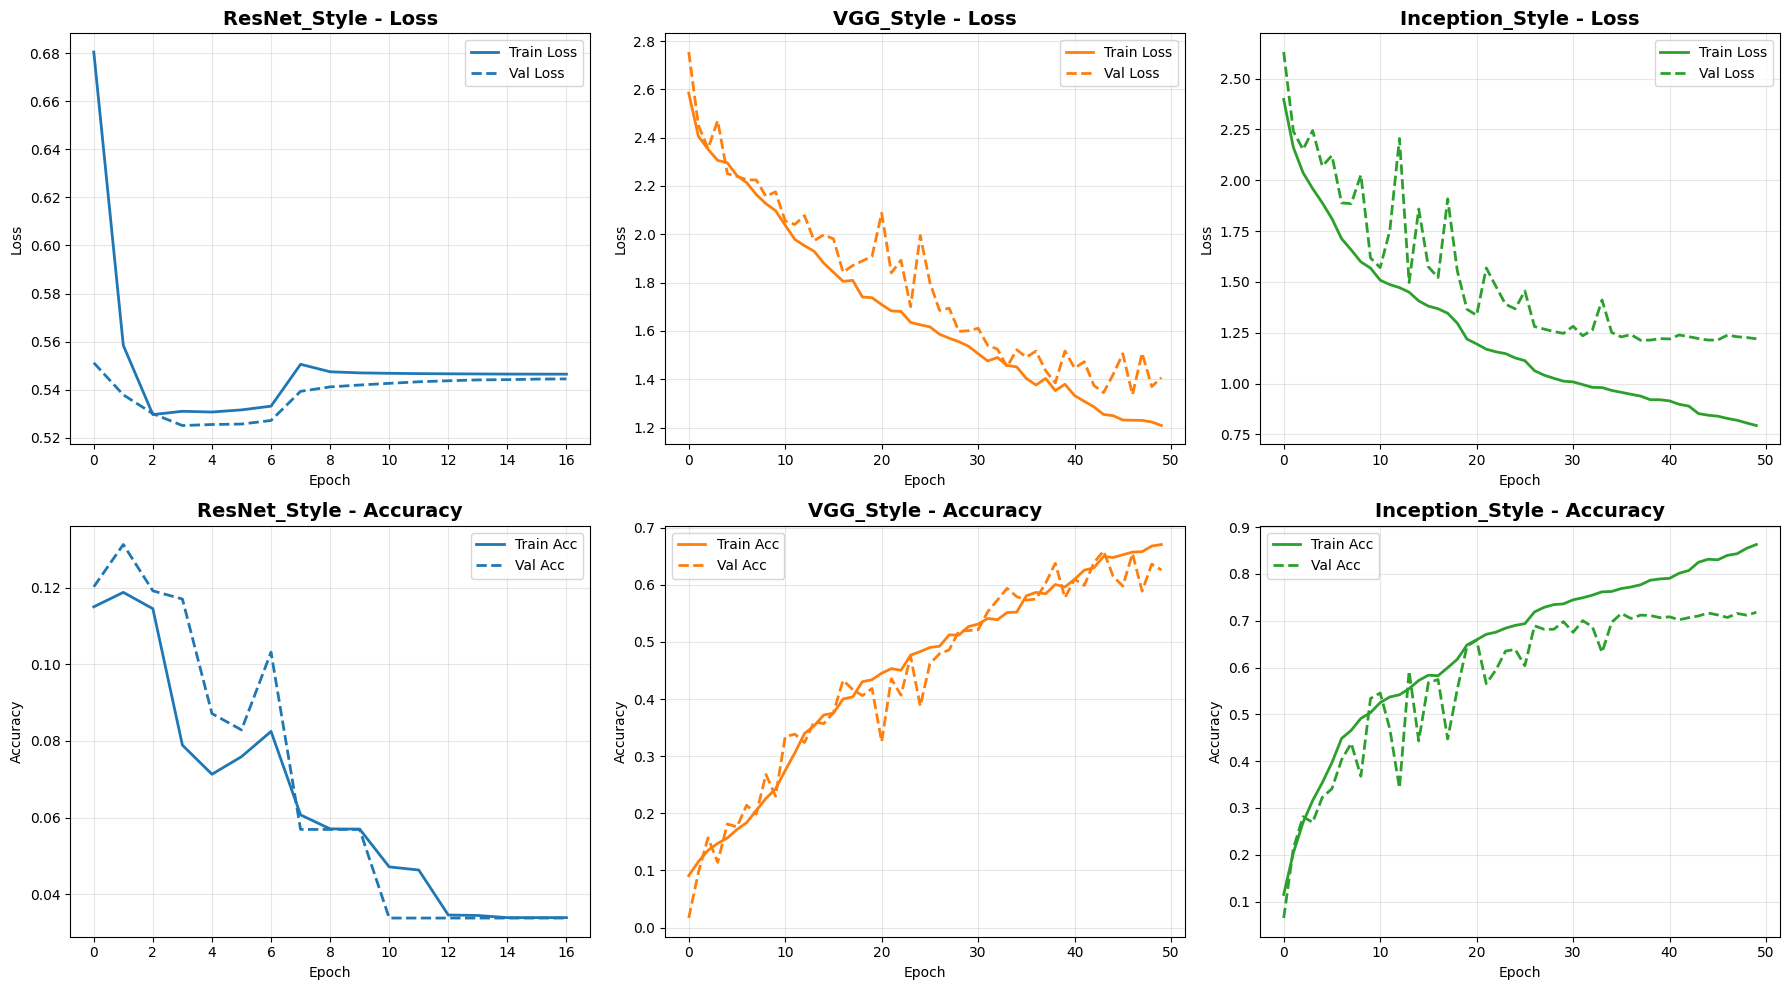

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colors = {'ResNet_Style': '#1f77b4', 'VGG_Style': '#ff7f0e', 'Inception_Style': '#2ca02c'}

for idx, (name, hist) in enumerate(histories.items()):
    # Loss curves
    axes[0, idx].plot(hist['loss'], label='Train Loss', color=colors[name], linewidth=2)
    axes[0, idx].plot(hist['val_loss'], label='Val Loss', color=colors[name], linestyle='--', linewidth=2)
    axes[0, idx].set_title(f'{name} - Loss', fontsize=14, fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[1, idx].plot(hist['accuracy'], label='Train Acc', color=colors[name], linewidth=2)
    axes[1, idx].plot(hist['val_accuracy'], label='Val Acc', color=colors[name], linestyle='--', linewidth=2)
    axes[1, idx].set_title(f'{name} - Accuracy', fontsize=14, fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Accuracy')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

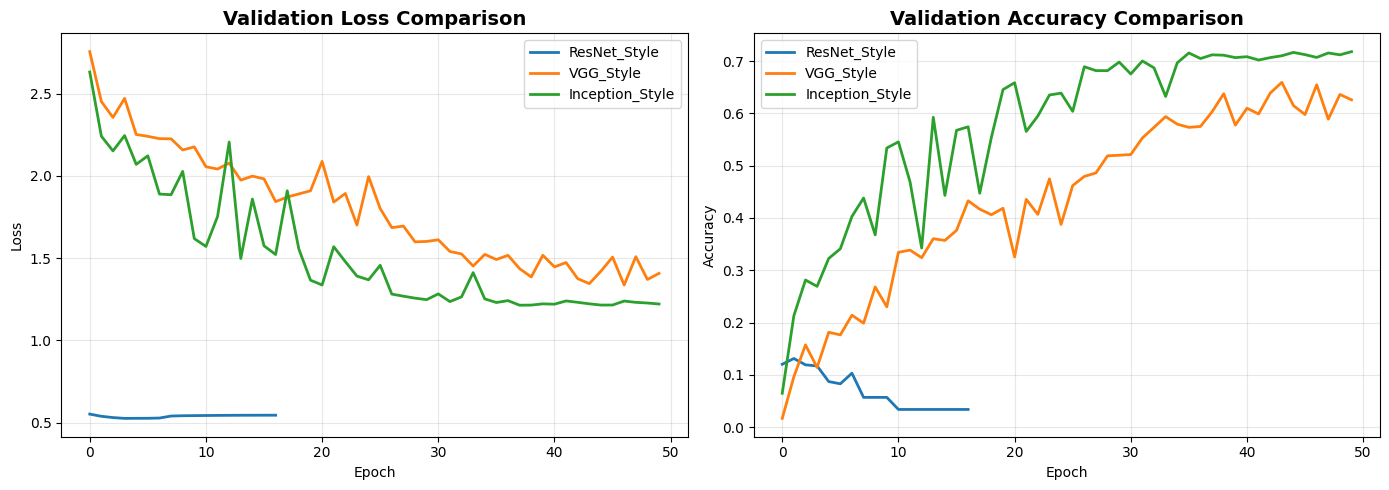

In [12]:
# Comparison plot: all models on same axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist in histories.items():
    axes[0].plot(hist['val_loss'], label=name, linewidth=2)
    axes[1].plot(hist['val_accuracy'], label=name, linewidth=2)

axes[0].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Evaluation and Confusion Matrices

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, model_name):
    """Evaluate model and return predictions."""
    y_true, y_pred = [], []
    all_images = []
    
    for ann in anns_valid:
        img = load_geoimage(ann.filename)
        t = tf.image.convert_image_dtype(tf.convert_to_tensor(img), tf.float32)
        t = tf.image.resize(t, [IMG_SIZE, IMG_SIZE], method='bilinear')
        all_images.append(t.numpy())
        y_true.append(ann.objects[0].category)
    
    X_valid = np.array(all_images)
    predictions = model.predict(X_valid, batch_size=128, verbose=0)
    
    cat_names = list(categories.values())
    y_pred = [cat_names[np.argmax(p)] for p in predictions]
    
    return y_true, y_pred, predictions

def plot_confusion_matrix(y_true, y_pred, title):
    """Plot normalized confusion matrix."""
    cat_names = list(categories.values())
    cm = confusion_matrix(y_true, y_pred, labels=cat_names)
    cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], 1e-10)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=cat_names, yticklabels=cat_names, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Ground Truth', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    return cm


Evaluating ResNet_Style


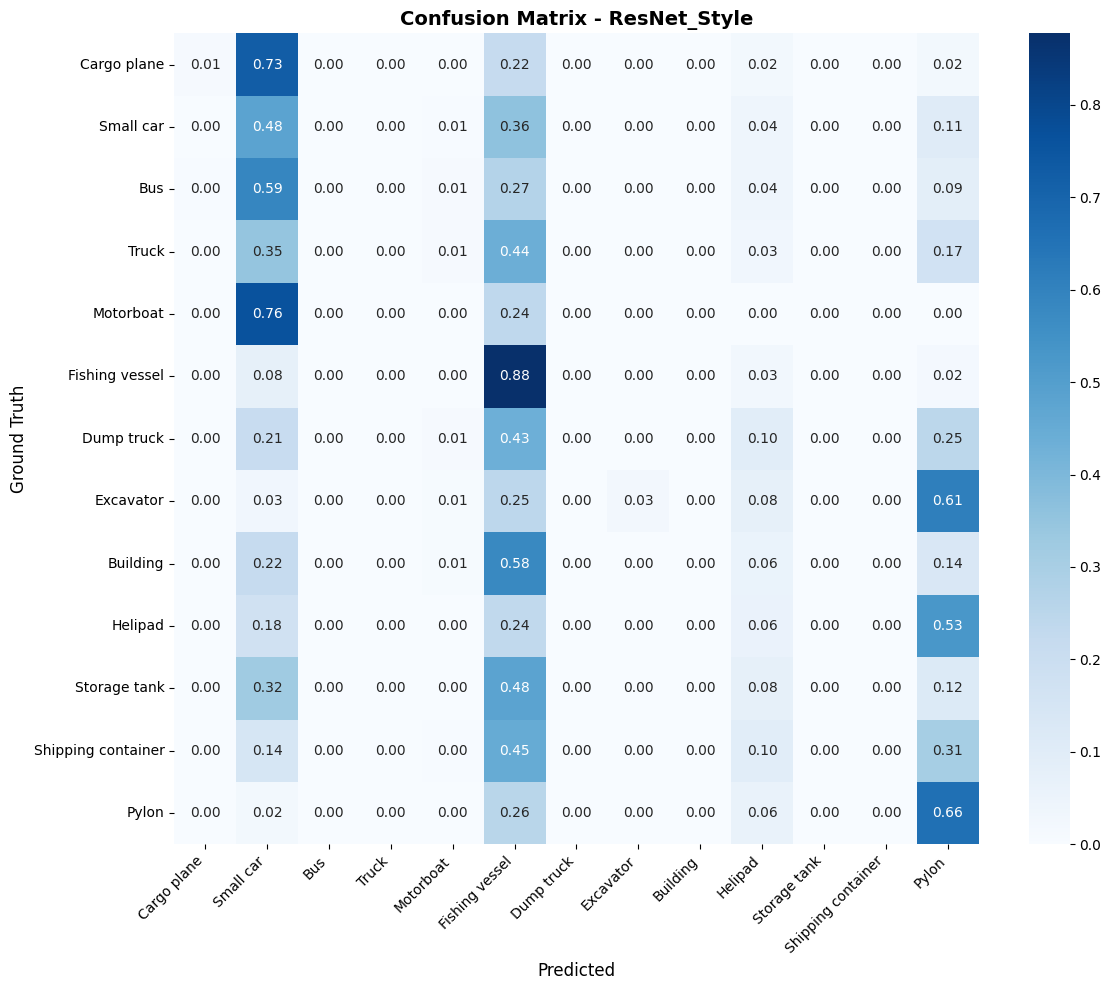


Accuracy: 13.12%
Mean Recall: 16.25%
Mean Precision: 11.38%

Evaluating VGG_Style


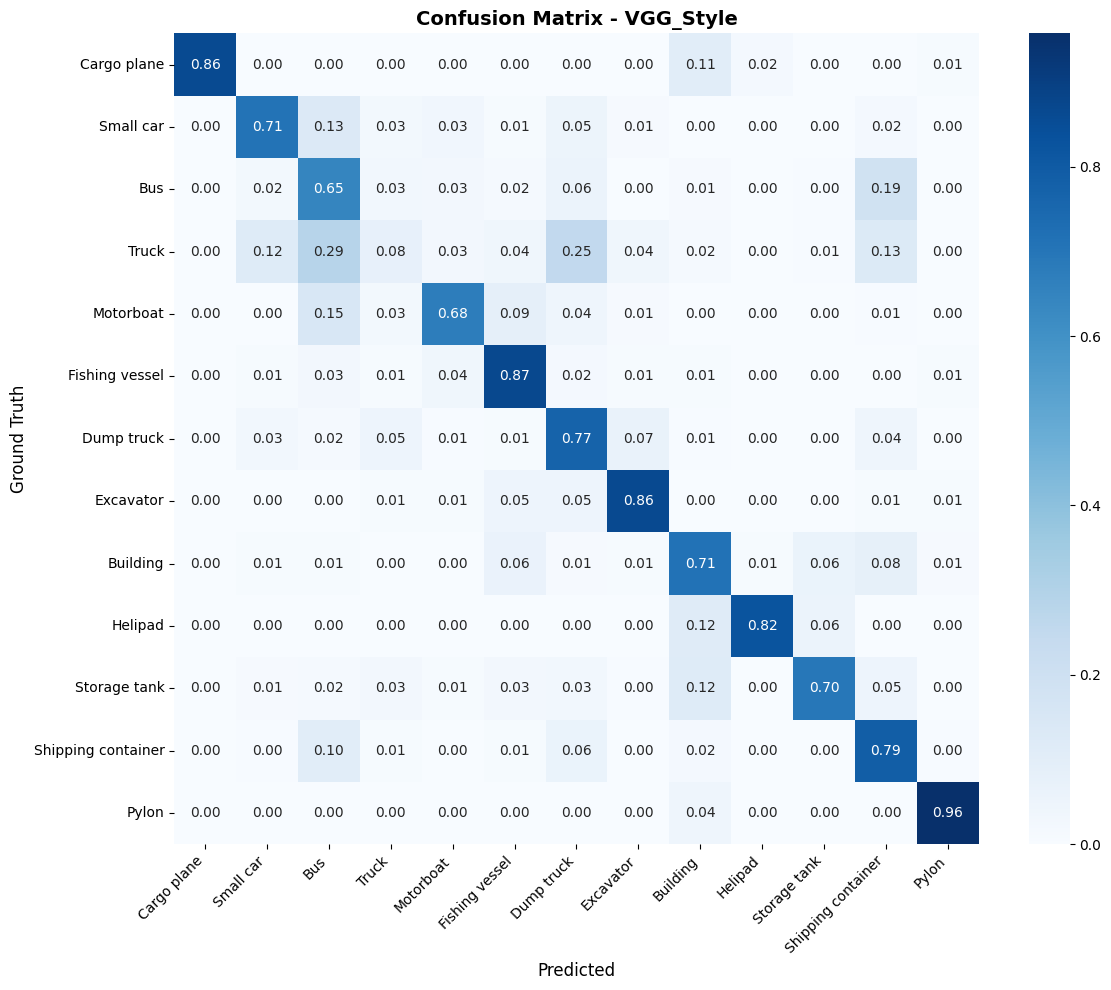


Accuracy: 65.93%
Mean Recall: 72.68%
Mean Precision: 66.78%

Evaluating Inception_Style


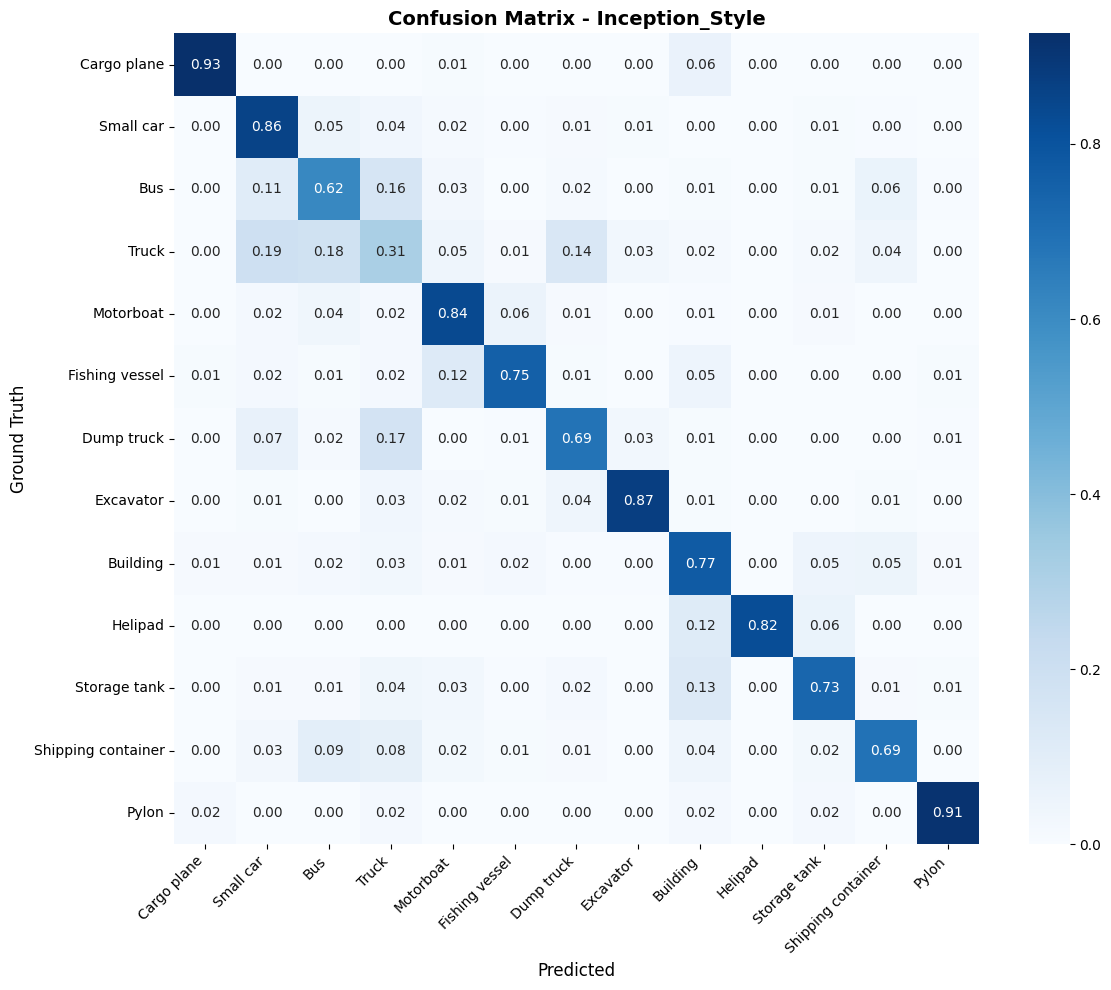


Accuracy: 71.80%
Mean Recall: 75.35%
Mean Precision: 74.01%


In [14]:
# Evaluate all models
results = {}

for name, model in models_dict.items():
    print(f"\n{'='*60}")
    print(f"Evaluating {name}")
    print(f"{'='*60}")
    
    y_true, y_pred, preds = evaluate_model(model, name)
    cm = plot_confusion_matrix(y_true, y_pred, f'Confusion Matrix - {name}')
    plt.savefig(f'confusion_matrix_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Compute metrics
    correct = np.diag(cm).astype(float)
    total_true = np.sum(cm, axis=1).astype(float)
    total_pred = np.sum(cm, axis=0).astype(float)
    
    accuracy = np.sum(correct) / np.sum(total_true) * 100
    recall = np.mean(correct / np.maximum(total_true, 1e-10)) * 100
    precision = np.mean(correct / np.maximum(total_pred, 1e-10)) * 100
    
    results[name] = {
        'accuracy': accuracy,
        'mean_recall': recall,
        'mean_precision': precision,
        'best_val_acc': max(histories[name]['val_accuracy']) * 100
    }
    
    print(f"\nAccuracy: {accuracy:.2f}%")
    print(f"Mean Recall: {recall:.2f}%")
    print(f"Mean Precision: {precision:.2f}%")

In [15]:
# Summary comparison table
print("\n" + "="*70)
print("SUMMARY: Custom CNN Architectures Comparison")
print("="*70)
print(f"{'Architecture':<20} {'Val Acc':<12} {'Accuracy':<12} {'Recall':<12} {'Precision':<12}")
print("-"*70)
for name, r in results.items():
    print(f"{name:<20} {r['best_val_acc']:.2f}%{'':<5} {r['accuracy']:.2f}%{'':<5} {r['mean_recall']:.2f}%{'':<5} {r['mean_precision']:.2f}%")
print("="*70)


SUMMARY: Custom CNN Architectures Comparison
Architecture         Val Acc      Accuracy     Recall       Precision   
----------------------------------------------------------------------
ResNet_Style         13.12%      13.12%      16.25%      11.38%
VGG_Style            65.93%      65.93%      72.68%      66.78%
Inception_Style      71.80%      71.80%      75.35%      74.01%


---
## Per-Class Performance Analysis

In [16]:
def compute_per_class_metrics(cm):
    """Compute per-class recall, precision, specificity, and F1-score."""
    metrics = []
    n_classes = cm.shape[0]
    
    for idx in range(n_classes):
        tp = cm[idx, idx]
        fp = np.sum(cm[:, idx]) - tp
        fn = np.sum(cm[idx, :]) - tp
        tn = np.sum(cm) - tp - fp - fn
        
        recall = tp / max(tp + fn, 1e-10)
        precision = tp / max(tp + fp, 1e-10)
        specificity = tn / max(tn + fp, 1e-10)
        f1 = 2 * precision * recall / max(precision + recall, 1e-10)
        
        metrics.append({
            'class': list(categories.values())[idx],
            'recall': recall * 100,
            'precision': precision * 100,
            'specificity': specificity * 100,
            'f1': f1 * 100
        })
    
    return metrics

# Best model per-class analysis
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nPer-class metrics for best model: {best_model_name}")
print("-"*80)

y_true, y_pred, _ = evaluate_model(models_dict[best_model_name], best_model_name)
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
metrics = compute_per_class_metrics(cm)

print(f"{'Class':<20} {'Recall':<12} {'Precision':<12} {'Specificity':<12} {'F1-Score':<12}")
print("-"*80)
for m in metrics:
    print(f"{m['class']:<20} {m['recall']:.2f}%{'':<5} {m['precision']:.2f}%{'':<5} {m['specificity']:.2f}%{'':<5} {m['f1']:.2f}%")


Per-class metrics for best model: Inception_Style
--------------------------------------------------------------------------------
Class                Recall       Precision    Specificity  F1-Score    
--------------------------------------------------------------------------------
Cargo plane          92.63%      91.67%      99.71%      92.15%
Small car            85.77%      77.26%      94.55%      81.29%
Bus                  61.51%      55.44%      94.86%      58.32%
Truck                31.33%      41.60%      94.11%      35.74%
Motorboat            83.75%      67.34%      97.55%      74.65%
Fishing vessel       75.47%      72.07%      98.85%      73.73%
Dump truck           68.65%      62.87%      97.15%      65.63%
Excavator            87.29%      82.40%      99.18%      84.77%
Building             77.18%      86.85%      97.23%      81.73%
Helipad              82.35%      100.00%      100.00%      90.32%
Storage tank         73.18%      77.03%      98.15%      75.06%
Shipping

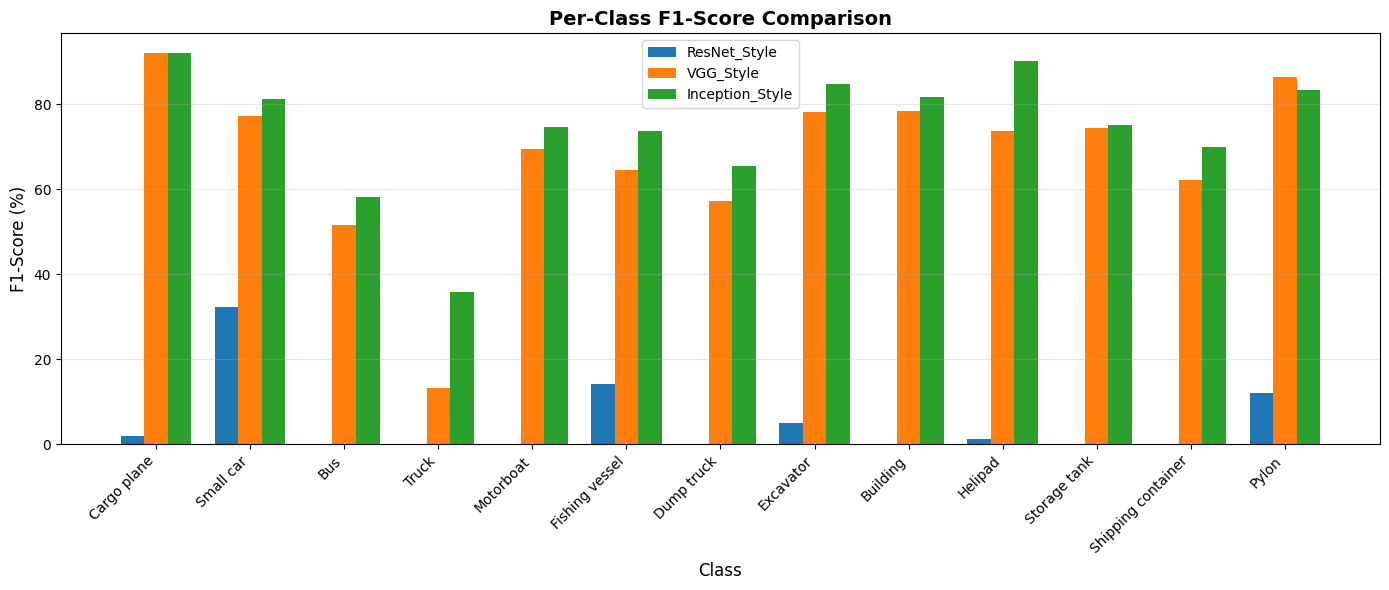

In [17]:
# Bar plot of per-class F1-scores for all models
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(categories))
width = 0.25

for i, (name, model) in enumerate(models_dict.items()):
    y_true, y_pred, _ = evaluate_model(model, name)
    cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
    metrics = compute_per_class_metrics(cm)
    f1_scores = [m['f1'] for m in metrics]
    
    ax.bar(x + i * width, f1_scores, width, label=name, color=list(colors.values())[i])

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('F1-Score (%)', fontsize=12)
ax.set_title('Per-Class F1-Score Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(list(categories.values()), rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('cnn_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Save Models

In [18]:
# Save all trained models
for name, model in models_dict.items():
    model.save(f'{name}_final.keras')
    print(f"Saved {name}_final.keras")

print("\nAll models saved.")

Saved ResNet_Style_final.keras
Saved VGG_Style_final.keras
Saved Inception_Style_final.keras

All models saved.
